In [16]:
from matplotlib import pyplot as plt
import numpy as np

import mne
import mne_icalabel
from asrpy import ASR

def load_subject_data(file_path):
    # Load the .set file using mne
    return mne.io.read_raw_eeglab(file_path, preload=True)

def notch_highpass_bads_rereference(data: mne.io.Raw, notch_freq=60, highpass_freq=1, bads=None):
    dataCopy = data.copy()
    dataCopy.notch_filter(freqs=notch_freq, verbose=False)
    dataCopy.filter(l_freq=highpass_freq, h_freq=None, verbose=False)
    if bads is not None:
        dataCopy.info['bads'].extend(bads)
    dataCopy.set_eeg_reference('average', verbose=False)
    return dataCopy

def run_ica(data: mne.io.Raw, n_components=None, exclude=None, plot_sources=False):
    dataCopy = data.copy()

    ica = mne.preprocessing.ICA(n_components=n_components, random_state=0, method='infomax', fit_params=dict(extended=True))
    ica.fit(dataCopy, verbose=False)
    ica.exclude = exclude
    if exclude is None:
        labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')
        ica.exclude = [idx for idx, label in enumerate(labels['labels']) if label != 'brain']
    else:
        ica.exclude = exclude
    if plot_sources:
        plot = ica.plot_sources(dataCopy)
    icaData = ica.apply(dataCopy, verbose=False)

    return icaData

def run_asr(data: mne.io.Raw, calibration_start=0, calibration_end=60, cutoff=10, win_overlap=0.9, max_bad_chans=0.1):
    dataCopy = data.copy()

    asr = ASR(dataCopy.info['sfreq'], cutoff=cutoff, win_overlap=win_overlap, max_bad_chans=max_bad_chans)
    asr.fit(dataCopy.copy().crop(calibration_start, calibration_end))
    asrData = asr.transform(dataCopy)
    asrData.set_eeg_reference('average', verbose=False)
    return asrData

def bandpass_filter(data: mne.io.Raw, l_freq, h_freq):
    return data.copy().filter(l_freq=l_freq, h_freq=h_freq, method="fir", verbose=False)

def convert_to_epochs(data: mne.io.Raw, e_start, e_end, tasks):
    epochs = mne.Epochs(data, tmin=e_start, tmax=e_end, baseline=None, preload=True, verbose=False)
    all_events = epochs.events[:, 2] # Get the event codes for the epochs before slicing
    return epochs[*tasks], all_events

To enable interactive plots, run the below snippet

In [17]:
%matplotlib ipympl

In [18]:
def load_and_preprocess(subject, run=3, bads=None, show_plots=False, n_components=15, ica_exclude=None, use_asr=True, base_start=1, base_end=4, data_start=0, data_end=3):
    file_path = f"EEG Motor Movement:Imagery Dataset/sub-{subject}/eeg/sub-{subject}_task-motion_run-{run}_eeg.set"
    data = load_subject_data(file_path)
    data = notch_highpass_bads_rereference(data, notch_freq=60, highpass_freq=1, bads=bads)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    data = run_ica(data, n_components, ica_exclude, plot_sources=show_plots)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    if use_asr:
        data = run_asr(data, cutoff=20, calibration_end=30)
        if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    data = bandpass_filter(data, 8, 30)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    return data

In [19]:
def alpha_change(baseline_epochs, left_task_epochs, right_task_epochs, events, band=(8,13)):
    # left_coi = ["Fc1", "Fc3", "C1", "C3", "Cp1", "Cp3"]
    # right_coi = ["Fc2", "Fc4", "C2", "C4", "Cp2", "Cp4"]
    # left_coi = ["Fc3", "C3", "Cp3"]
    # right_coi = ["Fc4", "C4", "Cp4"]
    left_coi = ["C3"]
    right_coi = ["C4"]
    left_channel_indices = [baseline_epochs.ch_names.index(ch) for ch in left_coi]
    right_channel_indices = [baseline_epochs.ch_names.index(ch) for ch in right_coi]

    baseline_epochs_copy = baseline_epochs.copy()
    left_task_epochs_copy = left_task_epochs.copy()
    right_task_epochs_copy = right_task_epochs.copy()
    
    baseline_epochs_copy.drop_channels(baseline_epochs_copy.info['bads'])
    left_task_epochs_copy.drop_channels(left_task_epochs_copy.info['bads'])
    right_task_epochs_copy.drop_channels(right_task_epochs_copy.info['bads'])

    # Mean over freqs (n_epochs, n_channels, n_freqs) --> (n_epochs, n_channels)
    base_mean_power = baseline_epochs_copy.compute_psd(fmin=band[0], fmax=band[1]).get_data().mean(axis=-1)
    base_left_brain = base_mean_power[:, left_channel_indices].mean(axis=-1) # Mean over channels of interest (n_epochs, n_channels) --> (n_epochs)
    base_right_brain = base_mean_power[:, right_channel_indices].mean(axis=-1)

    left_mean_power = left_task_epochs_copy.compute_psd(fmin=band[0], fmax=band[1]).get_data().mean(axis=-1)
    left_hand_left_brain = left_mean_power[:, left_channel_indices].mean(axis=-1)
    left_hand_right_brain = left_mean_power[:, right_channel_indices].mean(axis=-1)

    right_mean_power = right_task_epochs_copy.compute_psd(fmin=band[0], fmax=band[1]).get_data().mean(axis=-1)
    right_hand_left_brain = right_mean_power[:, left_channel_indices].mean(axis=-1)
    right_hand_right_brain = right_mean_power[:, right_channel_indices].mean(axis=-1)

    base_idx = 0
    left_idx = 0
    right_idx = 0

    modified_left_hand_left = []
    modified_left_hand_right = []
    modified_right_hand_left = []
    modified_right_hand_right = []

    for e in events:
        if e == 1:
            # This event is a base; get the base power values for subtraction.
            current_base_left = base_left_brain[base_idx]
            current_base_right = base_right_brain[base_idx]
            base_idx += 1
        elif e == 2:
            # This event is a left-hand trial: subtract the immediately preceding base.
            mod_lhlb = left_hand_left_brain[left_idx] - current_base_left
            mod_lhrb = left_hand_right_brain[left_idx] - current_base_right
            modified_left_hand_left.append(mod_lhlb)
            modified_left_hand_right.append(mod_lhrb)
            left_idx += 1
        elif e == 3:
            # This event is a right-hand trial: subtract the immediately preceding base.
            mod_rhlb = right_hand_left_brain[right_idx] - current_base_left
            mod_rhrb = right_hand_right_brain[right_idx] - current_base_right
            modified_right_hand_left.append(mod_rhlb)
            modified_right_hand_right.append(mod_rhrb)
            right_idx += 1

    return (np.array(modified_left_hand_left) * 1e12, np.array(modified_left_hand_right) * 1e12, 
            np.array(modified_right_hand_left) * 1e12, np.array(modified_right_hand_right) * 1e12)

This calculates the change in alpha power from the baseline period directly before a left or right hand motion to the epoch containing the motion

In [ ]:
subject_range_start = 1
subject_range_end = 2

base_start = 1
base_end = 4
data_start = 0
data_end = 2
mean_over_run = True
runs = [3, 7, 11] # 3, 7, 11 are the runs where the runs where the subject moved their left/right hand, all are identical

subjects = [f"{i:03d}" for i in range(subject_range_start, subject_range_end)]

all_lhlb = []
all_lhrb = []
all_rhlb = []
all_rhrb = []

for s in subjects:
    for r in runs:
        try:
            # Using default settings (bads=None, etc.)
            data = load_and_preprocess(s, run=r)
            baseline_epochs, all_events = convert_to_epochs(data, base_start, base_end, ["TASK1T0"])
            left_task_epochs, _ = convert_to_epochs(data, data_start, data_end, ["TASK1T1"])
            right_task_epochs, _ = convert_to_epochs(data, data_start, data_end, ["TASK1T2"])
            lhlb, lhrb, rhlb, rhrb = alpha_change(baseline_epochs, left_task_epochs, right_task_epochs, all_events)

            if mean_over_run:
                all_lhlb.append(lhlb.mean())
                all_lhrb.append(lhrb.mean())
                all_rhlb.append(rhlb.mean())
                all_rhrb.append(rhrb.mean())
            else:
                all_lhlb.extend(lhlb)
                all_lhrb.extend(lhrb)
                all_rhlb.extend(rhlb)
                all_rhrb.extend(rhrb)
        except Exception as e:
            print(f"Error processing subject {s} run {r}: {e}")

/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_97113/361665210.py:28: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_97113/361665210.py:28: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_97113/361665210.py:28: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


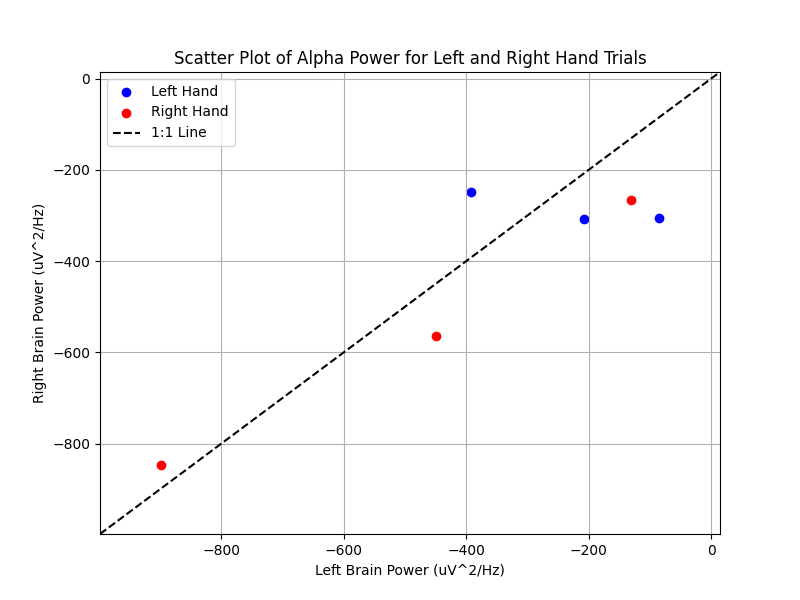

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(all_lhlb, all_lhrb, color='blue', label='Left Hand')
plt.scatter(all_rhlb, all_rhrb, color='red', label='Right Hand')
plt.xlabel('Left Brain Power (uV^2/Hz)')
plt.ylabel('Right Brain Power (uV^2/Hz)')
plt.title('Scatter Plot of Alpha Power for Left and Right Hand Trials')

# Determine limits from all data for same scaling
all_values = np.concatenate([all_lhlb, all_lhrb, all_rhlb, all_rhrb])
min_val = all_values.min()-100
max_val = all_values.max()+100
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Plot 1:1 line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

plt.legend()
plt.grid()
plt.show()

This attempts to classify the left and right hand epochs using CSP

In [ ]:
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score

subject_range_start = 1
subject_range_end = 21

data_start = 0
data_end = 2
runs = [3, 7, 11]

subjects = [f"{i:03d}" for i in range(subject_range_start, subject_range_end)]
all_epochs = []

for s in subjects:
    epochs_list = []
    for r in runs:
        try:
            data = load_and_preprocess(s, run=r)
            epochs_list.append(convert_to_epochs(data, data_start, data_end, ["TASK1T1", "TASK1T2"])[0])
        except Exception as e:
            print(f"Error processing subject {s} run {r}: {e}")

    combined_epochs = mne.concatenate_epochs(epochs_list) # Combine all runs
    all_epochs.append((s, combined_epochs))

In [ ]:
csp_component_range = range(5, 16)

all_data = []

for subj_epochs in all_epochs:

    subj_scores = []
    subj_stds = []

    # Create the input data X and binary labels y:
    X = subj_epochs[1].get_data()  # shape is (n_trials, n_channels, n_times)
    y = (subj_epochs[1].events[:, 2] == 3).astype(int)  # 1 if event==3 (right-hand), else 0

    for nc in csp_component_range:
        # Define the CSP transformer
        csp = CSP(n_components=nc, log=True, norm_trace=False)

        # Build a pipeline that applies CSP and then LDA
        clf = Pipeline([('CSP', csp),
                        ('LDA', LinearDiscriminantAnalysis())])

        # Evaluate the pipeline using stratified 5-fold cross-validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
        subj_scores.append(np.mean(scores))
        subj_stds.append(np.std(scores))

    argmax = np.argmax(subj_scores)
    all_data.append((subj_epochs[0], csp_component_range[argmax], subj_scores[argmax], subj_stds[argmax]))

In [30]:
for vals in all_data:
    print(f"{vals[0]}: CSP + LDA Classification accuracy: {vals[2]} ± {vals[3]} (best n_components={vals[1]})")

001: CSP + LDA Classification accuracy: 0.6 ± 0.20608041101101565 (best n_components=10)
002: CSP + LDA Classification accuracy: 0.6222222222222221 ± 0.16629588385661961 (best n_components=10)
003: CSP + LDA Classification accuracy: 0.5999999999999999 ± 0.08888888888888888 (best n_components=5)
004: CSP + LDA Classification accuracy: 0.5777777777777777 ± 0.19116278371205836 (best n_components=12)
005: CSP + LDA Classification accuracy: 0.5111111111111111 ± 0.20608041101101565 (best n_components=15)
006: CSP + LDA Classification accuracy: 0.6666666666666666 ± 0.07027283689263066 (best n_components=13)
007: CSP + LDA Classification accuracy: 0.8666666666666666 ± 0.10886621079036347 (best n_components=6)
008: CSP + LDA Classification accuracy: 0.5555555555555556 ± 0.1987615979999813 (best n_components=5)
009: CSP + LDA Classification accuracy: 0.5777777777777777 ± 0.19116278371205836 (best n_components=12)
010: CSP + LDA Classification accuracy: 0.6 ± 0.08888888888888888 (best n_component